In [1]:
import osmnx as ox
import networkx as nx
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── OSMnx v2 settings (replaces deprecated ox.config()) ──────────────────────
ox.settings.use_cache = True
ox.settings.log_console = True

print(f"OSMnx version: {ox.__version__}")

OSMnx version: 2.0.7


In [2]:
# ── Cities to compare ─────────────────────────────────────────────────────────
# You can swap these for any pair with good OSM coverage.
# Tip: use district/neighbourhood names for faster downloads, e.g.
#   "Centrum, Amsterdam, Netherlands"
#   "Garden City, Cairo, Egypt"

places = [
     "Central and Western District, Hong Kong",
    "Downtown Core, Singapore"
]

# ── Essential-service POI tags ─────────────────────────────────────────────────
TAGS = {
    "grocery":    {"shop":    ["supermarket", "convenience"]},
    "healthcare": {"amenity": ["hospital", "clinic", "pharmacy"]},
    "education":  {"amenity": ["school"]},
    "parks":      {"leisure": ["park"]},
    "transit":    {"highway": ["bus_stop"],
                   "railway": ["subway_entrance", "tram_stop"]},
}

# 15-minute walk ≈ 1125 m  (4.5 km/h × 15 min)
THRESHOLD_M = 1125

In [3]:
def get_pois(place: str, tags: dict, G) -> dict:
    """
    Fetch POIs for each category and reproject them to match the graph CRS.

    Parameters
    ----------
    place  : Nominatim place string
    tags   : dict mapping category name → OSM tag dict
    G      : PROJECTED OSMnx graph (output of ox.project_graph)
             
    Returns
    -------
    dict  : {category: GeoDataFrame of point geometries}
    """
    graph_crs = G.graph["crs"]   # Coordinate Reference System
    pois = {}

    print(f"  POI counts for '{place}':")
    for category, tag in tags.items():
        try:
            gdf = ox.features_from_place(place, tag)
        except Exception as exc:
            print(f"    {category:12s}: ERROR – {exc}")
            pois[category] = gpd.GeoDataFrame()
            continue

        if gdf.empty:
            print(f"    {category:12s}: 0 features found")
            pois[category] = gdf
            continue

        # Reproject to the same CRS as the walking network graph
        gdf = gdf.to_crs(graph_crs)
        # Convert polygons/lines to a single representative point
        gdf = gdf.copy()
        gdf["geometry"] = gdf.geometry.representative_point()

        print(f"    {category:12s}: {len(gdf)} features")
        pois[category] = gdf

    return pois

In [4]:
def compute_accessibility(place: str, tags: dict, threshold: float = THRESHOLD_M):
    """
    Compute per-node 15-minute accessibility scores for `place`.

    Returns
    -------
    nodes   : GeoDataFrame of network nodes (projected CRS)
    results : DataFrame with *_dist, *_access columns and an overall `score`
    """
    print(f"\n{'='*55}")
    print(f"  Analysing: {place}")
    print(f"{'='*55}")

    # Build walking network and project to a local metric CRS
    G = ox.graph_from_place(place, network_type="walk")
    G = ox.project_graph(G)
    nodes, edges = ox.graph_to_gdfs(G)
    print(f"  Network: {len(nodes):,} nodes, {len(edges):,} edges")

    # Fetch POIs — pass G so the function can use its CRS
    pois = get_pois(place, tags, G)

    results = pd.DataFrame(index=nodes.index)

    for category, gdf in pois.items():
        if gdf.empty or gdf.geometry.is_empty.all():
            results[f"{category}_dist"]   = np.inf
            results[f"{category}_access"] = 0
            continue

        # Snap each POI to its nearest graph node
        poi_nodes = ox.distance.nearest_nodes(
            G,
            gdf.geometry.x.values,
            gdf.geometry.y.values,
        )
        poi_nodes = list(set(poi_nodes))  # convert to list; set removes duplicates

        # Shortest walking distance from *any* POI node to every other node
        dist_dict = nx.multi_source_dijkstra_path_length(
            G, sources=poi_nodes, weight="length"
        )

        dist_series = pd.Series(dist_dict).reindex(nodes.index).fillna(np.inf)
        results[f"{category}_dist"]   = dist_series
        results[f"{category}_access"] = (dist_series <= threshold).astype(int)

    # Mean across all service categories → score in [0, 1]
    access_cols = [c for c in results.columns if c.endswith("_access")]
    results["score"] = results[access_cols].mean(axis=1)

    print(f"  Mean accessibility score: {results['score'].mean():.3f}")
    return nodes, results

In [5]:
# ── Run analysis for all cities ───────────────────────────────────────────────
city_results = {}

for place in places:
    nodes, res = compute_accessibility(place, TAGS)
    city_results[place] = {"nodes": nodes, "results": res}


  Analysing: Central and Western District, Hong Kong
  Network: 7,580 nodes, 21,860 edges
  POI counts for 'Central and Western District, Hong Kong':
    grocery     : 139 features
    healthcare  : 34 features
    education   : 47 features
    parks       : 56 features
    transit     : 641 features
  Mean accessibility score: 0.953

  Analysing: Downtown Core, Singapore
  Network: 2,597 nodes, 7,440 edges
  POI counts for 'Downtown Core, Singapore':
    grocery     : 53 features
    healthcare  : 28 features
    education   : 1 features
    parks       : 20 features
    transit     : 163 features
  Mean accessibility score: 0.869


In [6]:
# ── Comparative summary table ─────────────────────────────────────────────────
categories = list(TAGS.keys())

rows = []
for place, data in city_results.items():
    res = data["results"]
    row = {"City": place.split(",")[0]}
    for cat in categories:
        col = f"{cat}_access"
        row[cat.capitalize()] = f"{res[col].mean() * 100:.1f}%" if col in res else "N/A"
    row["Avg Score"] = f"{res['score'].mean():.3f}"
    row["Full Access %"] = f"{(res['score'] == 1.0).mean() * 100:.1f}%"
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("City")
print("\n" + "="*60)
print("  15-MINUTE CITY — COMPARATIVE SUMMARY")
print("="*60)
print(summary_df.to_string())


  15-MINUTE CITY — COMPARATIVE SUMMARY
                             Grocery Healthcare Education  Parks Transit Avg Score Full Access %
City                                                                                            
Central and Western District   95.3%      90.1%     95.3%  97.7%   98.1%     0.953         89.2%
Downtown Core                  99.2%      97.6%     46.1%  91.8%  100.0%     0.869         46.1%


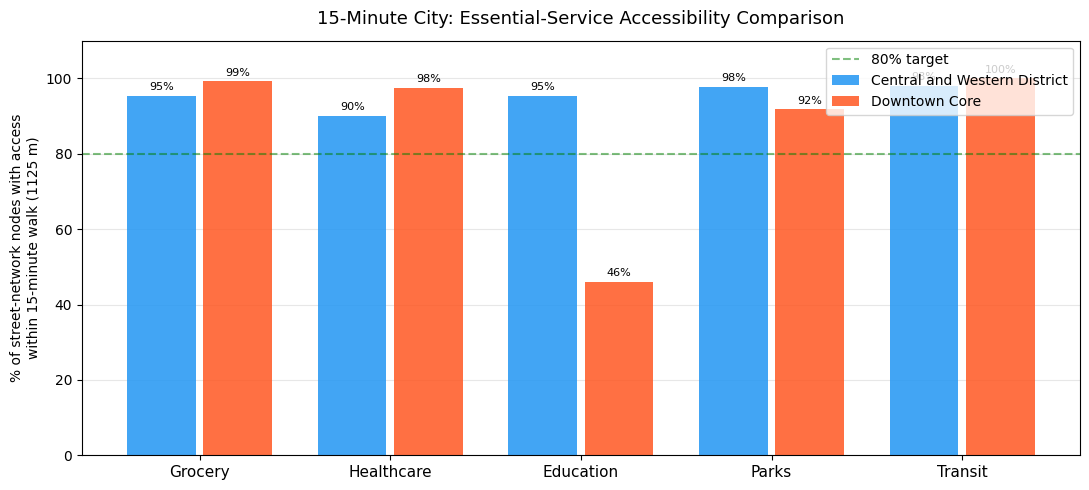

In [7]:
# ── Bar chart: per-category access rates ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

n_cities = len(places)
n_cats   = len(categories)
bar_w    = 0.8 / n_cities
x        = np.arange(n_cats)
colours  = ["#2196F3", "#FF5722", "#4CAF50", "#9C27B0"]

for i, (place, data) in enumerate(city_results.items()):
    res = data["results"]
    pcts = [res[f"{cat}_access"].mean() * 100 if f"{cat}_access" in res else 0
            for cat in categories]
    offset = (i - (n_cities - 1) / 2) * bar_w
    bars = ax.bar(x + offset, pcts, width=bar_w * 0.9,
                  label=place.split(",")[0], color=colours[i % len(colours)], alpha=0.85)
    for bar, pct in zip(bars, pcts):
        if pct > 5:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                    f"{pct:.0f}%", ha="center", va="bottom", fontsize=8)

ax.axhline(y=80, color="green", linestyle="--", alpha=0.5, label="80% target")
ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in categories], fontsize=11)
ax.set_ylabel("% of street-network nodes with access\nwithin 15-minute walk (1125 m)", fontsize=10)
ax.set_title("15-Minute City: Essential-Service Accessibility Comparison", fontsize=13, pad=12)
ax.set_ylim(0, 110)
ax.legend(loc="upper right", fontsize=10)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("15min_city_bar_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

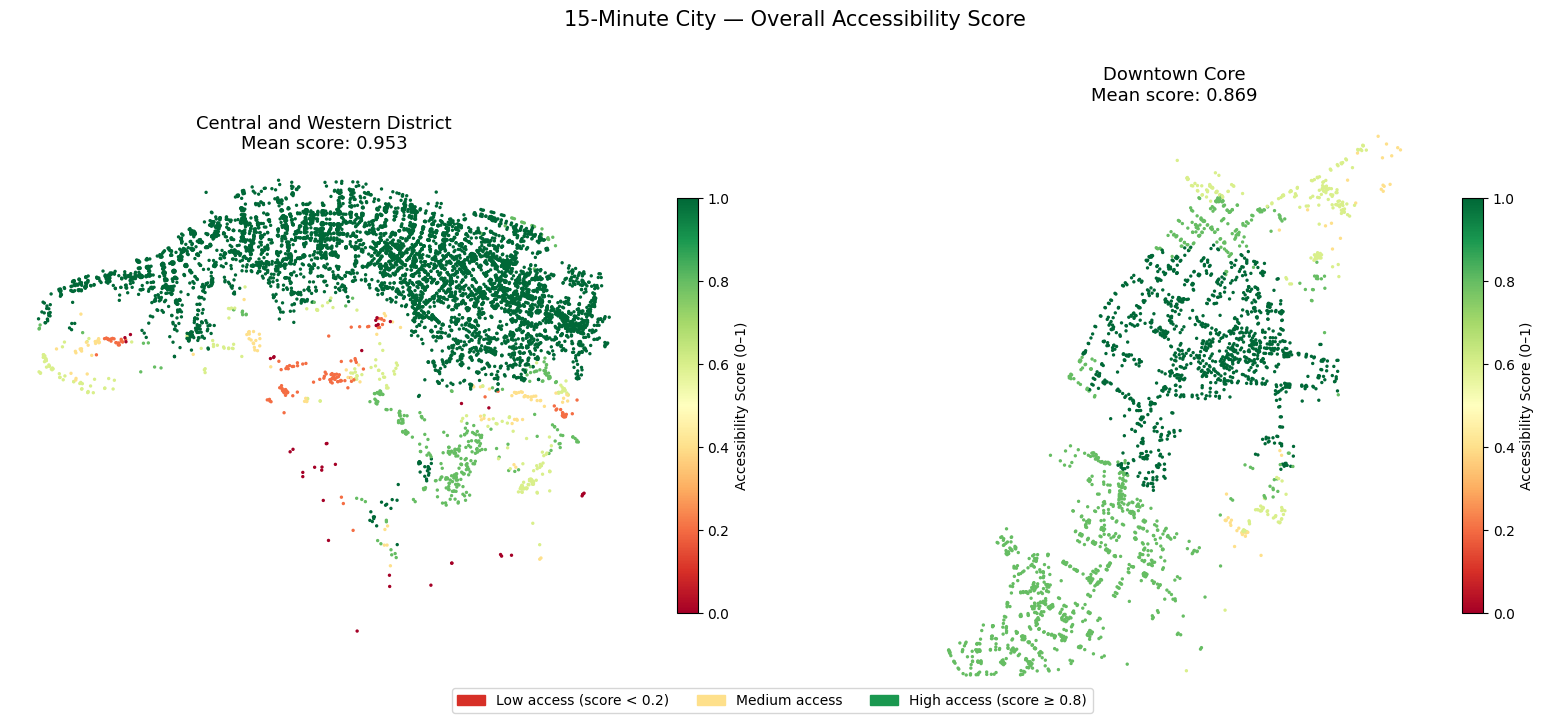

In [8]:
# ── Side-by-side accessibility score maps ────────────────────────────────────
n_cols = len(places)
fig, axes = plt.subplots(1, n_cols, figsize=(8 * n_cols, 7))
if n_cols == 1:
    axes = [axes]

for ax, place in zip(axes, places):
    nodes = city_results[place]["nodes"].copy()
    res   = city_results[place]["results"]
    nodes["score"] = res["score"]

    nodes.plot(
        column="score", ax=ax,
        cmap="RdYlGn",
        markersize=2,
        legend=True,
        vmin=0, vmax=1,
        legend_kwds={"label": "Accessibility Score (0–1)", "shrink": 0.7},
    )
    city_short = place.split(",")[0]
    ax.set_title(f"{city_short}\nMean score: {res['score'].mean():.3f}", fontsize=13)
    ax.axis("off")

# Legend patches
legend_elements = [
    mpatches.Patch(color="#d73027", label="Low access (score < 0.2)"),
    mpatches.Patch(color="#fee08b", label="Medium access"),
    mpatches.Patch(color="#1a9850", label="High access (score ≥ 0.8)"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, fontsize=10, frameon=True)

plt.suptitle("15-Minute City — Overall Accessibility Score", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("15min_city_maps.png", dpi=150, bbox_inches="tight")
plt.show()

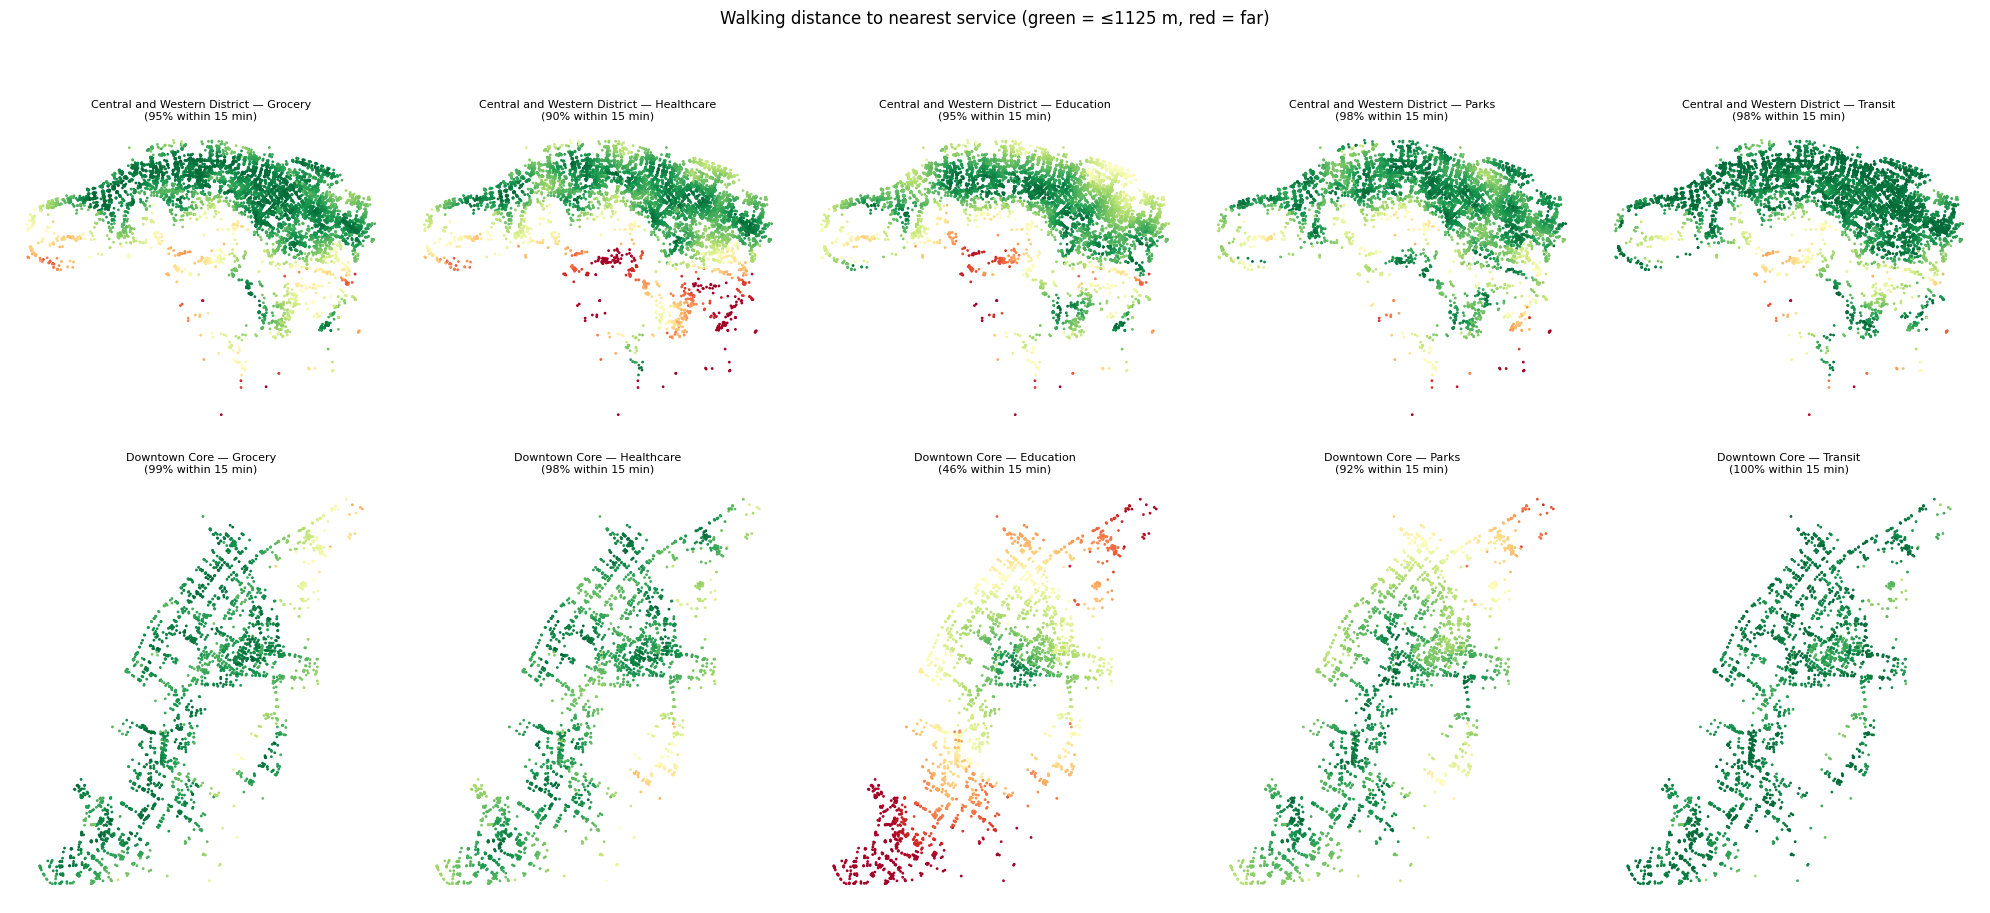

In [9]:
# ── Per-category distance maps (one row per city) ────────────────────────────
n_rows = len(places)
n_cols = len(categories)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4.5 * n_rows))
# Ensure always 2-D array
if n_rows == 1:
    axes = axes[np.newaxis, :]

for row, place in enumerate(places):
    nodes = city_results[place]["nodes"].copy()
    res   = city_results[place]["results"]
    city_short = place.split(",")[0]

    for col, cat in enumerate(categories):
        ax       = axes[row, col]
        dist_col = f"{cat}_dist"
        acc_col  = f"{cat}_access"

        if dist_col in res.columns:
            # Clip distances for colour range clarity
            nodes[dist_col] = res[dist_col].clip(upper=THRESHOLD_M * 2)
            nodes.plot(
                column=dist_col, ax=ax,
                cmap="RdYlGn_r",
                markersize=1,
                legend=False,
                vmin=0, vmax=THRESHOLD_M * 2,
            )
            pct = res[acc_col].mean() * 100 if acc_col in res else 0
            ax.set_title(
                f"{city_short} — {cat.capitalize()}\n({pct:.0f}% within 15 min)",
                fontsize=8
            )
        else:
            ax.set_title(f"{city_short} — {cat.capitalize()}\n(no data)", fontsize=8)
        ax.axis("off")

plt.suptitle(
    f"Walking distance to nearest service (green = ≤{THRESHOLD_M} m, red = far)",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig("15min_city_category_maps.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# ── Detailed statistics per city ──────────────────────────────────────────────
for place, data in city_results.items():
    res = data["results"]
    print(f"\n{'─'*55}")
    print(f"  {place}")
    print(f"{'─'*55}")
    print(f"  {'Category':<14} {'Mean dist (m)':>14} {'Max dist (m)':>13} {'% accessible':>13}")
    print(f"  {'-'*14} {'-'*14} {'-'*13} {'-'*13}")
    for cat in categories:
        d  = f"{cat}_dist"
        a  = f"{cat}_access"
        if d in res:
            finite = res[d].replace(np.inf, np.nan)
            mean_d = finite.mean()
            max_d  = finite.max()
            pct    = res[a].mean() * 100
            mean_s = f"{mean_d:>14,.0f}" if not np.isnan(mean_d) else f"{'N/A':>14}"
            max_s  = f"{max_d:>13,.0f}"  if not np.isnan(max_d)  else f"{'N/A':>13}"
            print(f"  {cat.capitalize():<14} {mean_s} {max_s} {pct:>12.1f}%")
    print(f"\n  Overall mean score : {res['score'].mean():.3f}")
    print(f"  Fully accessible   : {(res['score'] == 1.0).mean() * 100:.1f}% of nodes")


───────────────────────────────────────────────────────
  Central and Western District, Hong Kong
───────────────────────────────────────────────────────
  Category        Mean dist (m)  Max dist (m)  % accessible
  -------------- -------------- ------------- -------------
  Grocery                   285         2,488         95.3%
  Healthcare                477         4,439         90.1%
  Education                 466         2,773         95.3%
  Parks                     324         3,102         97.7%
  Transit                   164         2,244         98.1%

  Overall mean score : 0.953
  Fully accessible   : 89.2% of nodes

───────────────────────────────────────────────────────
  Downtown Core, Singapore
───────────────────────────────────────────────────────
  Category        Mean dist (m)  Max dist (m)  % accessible
  -------------- -------------- ------------- -------------
  Grocery                   250         1,590         99.2%
  Healthcare                328      